# Task A1 - mutation comparison

In [1]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data'/ 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / 'data'/ '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

SIGNAL_COL = 'ERKKTR_ratio'
print('Setup complete.')

Setup complete.


---
## Metadata overview

A quick look at which site belongs to which mutation.

In [3]:
meta = pd.read_csv(META_PATH, encoding='utf-8-sig')
meta.rename(columns={'Site': 'Image_Metadata_Site'}, inplace=True)
print(meta[['Image_Metadata_Site', 'Mutation']].to_string(index=False))

 Image_Metadata_Site      Mutation
                   1            WT
                   2            WT
                   3            WT
                   4            WT
                   5     AKT1_E17K
                   6     AKT1_E17K
                   7     AKT1_E17K
                   8     AKT1_E17K
                   9  PIK3CA_E545K
                  10  PIK3CA_E545K
                  11  PIK3CA_E545K
                  12  PIK3CA_E545K
                  13 PIK3CA_H1047R
                  14 PIK3CA_H1047R
                  15 PIK3CA_H1047R
                  16 PIK3CA_H1047R
                  17      PTEN_del
                  18      PTEN_del
                  19      PTEN_del
                  20      PTEN_del
                  21      PTEN_del
                  22      PTEN_del
                  23      PTEN_del
                  24      PTEN_del
                  25         ErbB2
                  26         ErbB2
                  27         ErbB2
                  28

## Task A1 - Multi-Mutation Spatiotemporal Comparison

In [4]:
print('Running comparative analysis …')
cmd_compare = [
    sys.executable,
    str(SCRIPTS_DIR / 'compare_spatiotemporal_behavior.py'),
    '--data-path', str(DATA_PATH),
    '--meta-path', str(META_PATH),
    '--signal-col', SIGNAL_COL,
    '--group-by', 'mutation',
    '--spatial-radius', '60',
    '--future-window-frames', '3',
    '--jump-quantile', '0.9',
    '--exclude-mutations', 'ErbB2',
    '--output-dir', str(OUTPUT_ROOT),
]
result = subprocess.run(cmd_compare, capture_output=True, text=True)
print('done!')

Running comparative analysis …
done!


In [2]:
# results loading
summary_dir = OUTPUT_ROOT / f'comparison_mutation_{SIGNAL_COL}'

# extracting averages from group_level_summary.csv (as in the instructions)
group_df = pd.read_csv(summary_dir/'group_level_summary.csv')

# extracting raw data for testing
block_df = pd.read_csv(summary_dir/'block_level_summary.csv')

mutations = ['WT', 'AKT1_E17K', 'PIK3CA_E545K', 'PIK3CA_H1047R', 'PTEN_del']

wt_values = block_df[block_df['comparison_group'] == 'WT']['relative_risk']

final_results = []
num_comparisons = 4 # we are comparing 4 mutants to the WT

In [3]:
# statistics tests
for mut in mutations:
    mean_rr = group_df.loc[group_df['comparison_group'] == mut, 'mean_relative_risk'].values[0]
    
    mut_values = block_df[block_df['comparison_group'] == mut]['relative_risk']
    se_rr = mut_values.sem()
    
    if mut == 'WT':
        p_adj = np.nan
        is_sig = False
    else:
        # Mann-Whitney test
        _, p = mannwhitneyu(mut_values, wt_values)
        p_adj = min(p * 4, 1.0) # Bonferroni
        is_sig = p_adj < 0.05
        
    final_results.append({
        'mutation': mut, 
        'mean_RR': mean_rr, 
        'std_error': se_rr, 
        'p_value_vs_WT': p_adj, 
        'significant': is_sig
    })

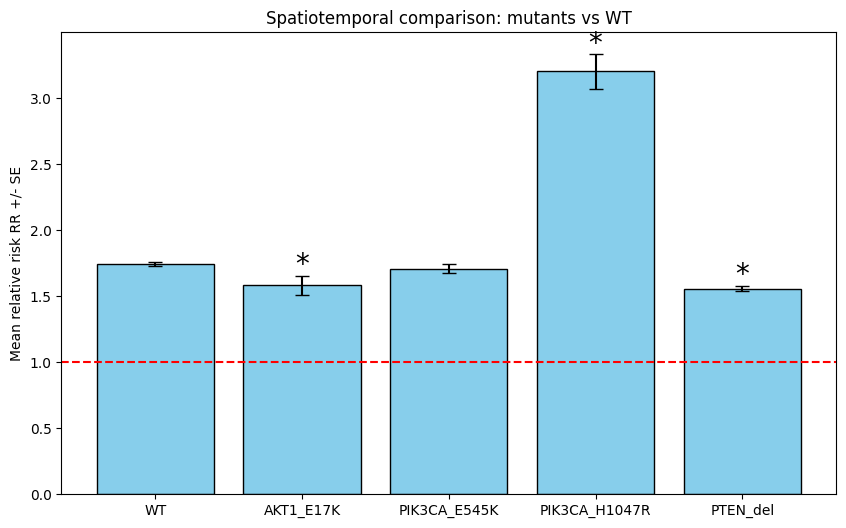

,mutation,mean_RR,std_error,p_value_vs_WT,significant
0,WT,1.742349,0.017193,NaN,False
1,AKT1_E17K,1.581421,0.071932,1.384587e-02,True
2,PIK3CA_E545K,1.707110,0.031885,7.341158e-01,False
3,PIK3CA_H1047R,3.200310,0.130643,1.225466e-08,True
4,PTEN_del,1.556633,0.021624,1.464234e-06,True


In [4]:
# plot, table, saving
results_df = pd.DataFrame(final_results)
results_df.to_csv('../outputs/mutations_comparison_table.csv', index=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['mutation'], results_df['mean_RR'], yerr=results_df['std_error'], capsize=5, color='skyblue', edgecolor='black')
plt.axhline(1, color='red', linestyle='--')
plt.ylabel('Mean relative risk RR +/- SE')
plt.title('Spatiotemporal comparison: mutants vs WT')

# significance markers
for i, row in results_df.iterrows():
    if row['significant']:
        plt.text(i, row['mean_RR'] + row['std_error'] + 0.02, '*', ha='center', fontsize=20)

plt.show()
display(results_df)

Interpretation (150–250 words): Which mutations differ? Propose biological mechanism.